In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import statsmodels.api as sm

from catboost import CatBoostRegressor

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,  OneHotEncoder
from sklearn.decomposition import TruncatedSVD,PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
data_0 = pd.read_csv("../data/house_prices.csv")

In [3]:
data_0.head(10)

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN
5,5,1 BHK Ready to Occupy Flat for sale in Virat A...,Creatively planned and constructed is a 1 BHK ...,45 Lac,6618.0,thane,NaN,Ready to Move,2 out of 7,Resale,...,East,"Garden/Park, Main Road",Virat Aangan,1,1,NaN,Co-operative Society,680 sqft,NaN,NaN
6,6,1 BHK Ready to Occupy Flat for sale Mumbra,This magnificent 1 BHK Flat is available for s...,16.5 Lac,2538.0,thane,550 sqft,Ready to Move,4 out of 5,Resale,...,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
7,7,1 BHK Ready to Occupy Flat for sale Kalwa,Creatively planned and constructed is a 1 BHK ...,60 Lac,10435.0,thane,NaN,Ready to Move,Ground out of 7,Resale,...,NaN,NaN,NaN,1,NaN,NaN,NaN,575 sqft,NaN,NaN
8,8,1 BHK Ready to Occupy Flat for sale Kalwa,Discover this immaculate 1 BHK flat for sale a...,60 Lac,10000.0,thane,NaN,Ready to Move,Ground out of 2,Resale,...,NaN,NaN,NaN,1,NaN,NaN,Co-operative Society,600 sqft,NaN,NaN
9,9,3 BHK Ready to Occupy Flat for sale in Pride P...,One can find this stunning 3 BHK flat for sale...,1.60 Cr,11150.0,thane,900 sqft,Ready to Move,3 out of 27,Resale,...,East,Garden/Park,Pride Palms,3,1,1 Covered,Freehold,NaN,NaN,NaN


In [4]:
data_0.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [5]:
def split_and_convert_units(s: pd.Series, factors: dict) -> pd.Series:
    parts = s.str.split(" ", n=1, expand=True)
    units = parts[1].str.strip().map(factors)
    return parts[0].astype(float) * units


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(subset=["Price (in rupees)", "Carpet Area"]).reset_index(drop=True)

    # Amount, Carpet Area
    df["Amount(in rupees)"] = split_and_convert_units(df["Amount(in rupees)"], {"Lac": 1e5, "Cr": 1e7})
    df["Carpet Area (sqm)"] = split_and_convert_units(df["Carpet Area"], {
        "sqft": 0.092903, "sqm": 1, "sqyrd": 0.836127, "acre": 4046.86,
        "ground": 101.17, "bigha": 2529.81, "marla": 25.2929, "kanal": 202.34,
    })

    # Floors
    floors = df["Floor"].str.split(" out of ", n=1, expand=True)
    floors[0] = floors[0].replace({"Ground": 0, "Upper Basement": -1, "Lower Basement": -2})
    df["Floor Number"], df["Total Floors"] = [floors[i].fillna(0).astype(int) for i in (0, 1)]

    # Balcony, Bathroom
    for col in ["Balcony", "Bathroom"]:
        df[col] = pd.to_numeric(df[col].fillna(0).replace("> 10", 11), errors="coerce").astype(int)

    # Car parking
    parking = df["Car Parking"].str.split(" ", n=1, expand=True)
    df["Car Parking Number"] = parking[0].fillna(0).astype(int)
    df["Car Parking Type"] = parking[1].replace("Covered,", "Covered")
    
    df.drop(columns=["Description", "Index", "Carpet Area", "Floor", "Price (in rupees)",
                     "Plot Area", "Dimensions", "Super Area", "Car Parking", "Status", "Society"])
    
    return df[['Title', 'Amount(in rupees)', 'location',
               'Transaction', 'Furnishing', 'facing', 'overlooking',
               'Ownership', 'Bathroom', 'Balcony',  'Carpet Area (sqm)', 'Floor Number',
               'Total Floors', 'Car Parking Number', 'Car Parking Type']]

data_1 = feature_engineering(data_0)
print(data_1.info())


<class 'pandas.DataFrame'>
RangeIndex: 93631 entries, 0 to 93630
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Title               93631 non-null  str    
 1   Amount(in rupees)   93631 non-null  float64
 2   location            93631 non-null  str    
 3   Transaction         93628 non-null  str    
 4   Furnishing          93608 non-null  str    
 5   facing              77754 non-null  str    
 6   overlooking         72158 non-null  str    
 7   Ownership           79235 non-null  str    
 8   Bathroom            93631 non-null  int64  
 9   Balcony             93631 non-null  int64  
 10  Carpet Area (sqm)   93631 non-null  float64
 11  Floor Number        93631 non-null  int64  
 12  Total Floors        93631 non-null  int64  
 13  Car Parking Number  93631 non-null  int64  
 14  Car Parking Type    56716 non-null  str    
dtypes: float64(2), int64(5), str(8)
memory usage: 10.7 MB
None


In [6]:
target = "Amount(in rupees)"

numerical_columns = (data_1.select_dtypes(include=["int64", "float64"]).columns.drop(target).tolist())

df_model = data_1[[target] + numerical_columns].copy()

df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

df_model = df_model[(df_model[target] > 0) &(df_model[numerical_columns] > 0).all(axis=1)]

X = np.log(df_model[numerical_columns])
y = np.log(df_model[target])

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

elasticity = pd.DataFrame({
    "feature": numerical_columns,
    "elasticity": model.params[numerical_columns].values,
    "p_value": model.pvalues[numerical_columns].values,
    "ci_lower": model.conf_int().loc[numerical_columns, 0].values,
    "ci_upper": model.conf_int().loc[numerical_columns, 1].values
})

elasticity["abs_elasticity"] = elasticity["elasticity"].abs()

elasticity = (elasticity.sort_values("abs_elasticity", ascending=False).reset_index(drop=True))

elasticity

,feature,elasticity,p_value,ci_lower,ci_upper,abs_elasticity
0,Carpet Area (sqm),0.902503,0.000000e+00,0.888990,0.916016,0.902503
1,Bathroom,0.615036,0.000000e+00,0.594885,0.635186,0.615036
2,Balcony,0.118806,2.330512e-139,0.109568,0.128044,0.118806
3,Total Floors,0.089483,1.963879e-80,0.080265,0.098702,0.089483
4,Floor Number,0.051093,2.811981e-34,0.042896,0.059290,0.051093
5,Car Parking Number,0.021393,9.585107e-13,0.015519,0.027267,0.021393


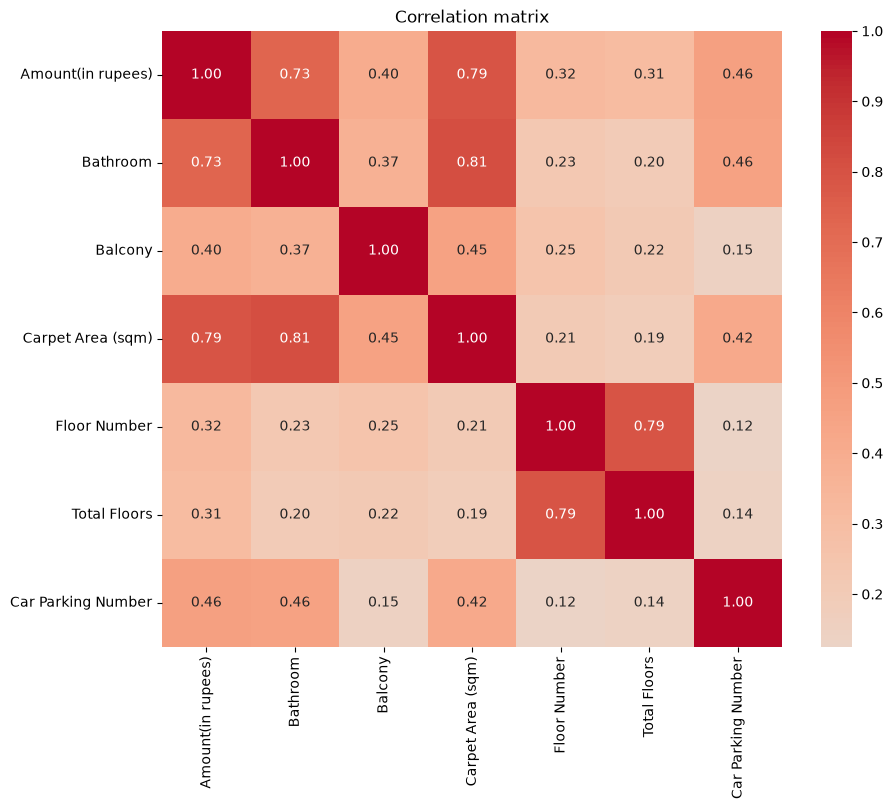

In [7]:
categorial_columns = data_1.select_dtypes(include=["str"]).columns.tolist()
numerical_columns = data_1.select_dtypes(include=["int64", "float64"]).columns.tolist()
data_2 = data_1.copy()

data_2["Amount(in rupees)"] = np.log(data_2["Amount(in rupees)"])
data_2["Carpet Area (sqm)"] = np.log(data_2["Carpet Area (sqm)"])

#cut outliers
outlier_cols = [
    "Carpet Area (sqm)",
    "Car Parking Number",
]

for col in outlier_cols:
    q1 = data_2[col].quantile(0.25)
    q3 = data_2[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    data_2 = data_2[data_2[col].between(lower, upper)]

#corr graph
plt.figure(figsize=(10, 8))
sns.heatmap(data_2[numerical_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

===== Linear Reg =====
R2   = 0.925
MAE  = 0.091
RMSE = 0.225
TIME = 8.971

===== CatBoost =========
R2   = 0.947
MAE  = 0.085
RMSE = 0.189
TIME = 41.466


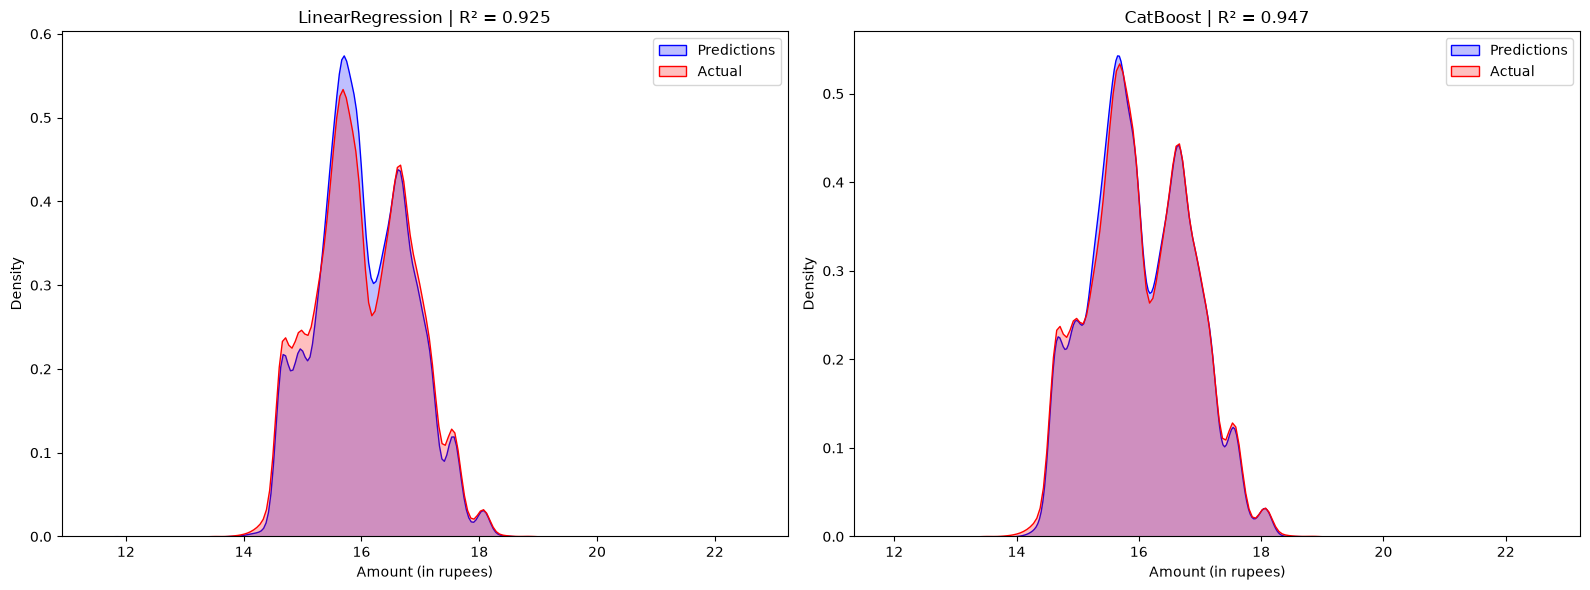

In [8]:
#LinearReg OneHotEncoder
target = "Amount(in rupees)"

X = data_2.drop(columns=[target]).copy()
y = data_2[target]

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

X[categorical_columns] = X[categorical_columns].fillna("NaN").astype(str)
X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].median())

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_columns),
        ("num", "passthrough", numeric_columns)
    ]
)

X_train, X_test, y_train_linreg, y_test_linreg = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

start = time.perf_counter()

model = LinearRegression()
model.fit(X_train_encoded, y_train_linreg)
fit_time_linreg = time.perf_counter() - start

y_pred_linreg = model.predict(X_test_encoded)

r2_linreg = r2_score(y_test_linreg, y_pred_linreg)
mae_linreg = mean_absolute_error(y_test_linreg, y_pred_linreg)
rmse_linreg = np.sqrt(mean_squared_error(y_test_linreg, y_pred_linreg))

#CatBoost
X = data_2.drop(columns=[target]).copy()
y = data_2[target]

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

X[categorical_columns] = X[categorical_columns].fillna("NaN").astype(str)
X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].median())

X_train, X_test, y_train_catboost, y_test_catboost = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

model = CatBoostRegressor(
    iterations=2000,
    depth=10,
    learning_rate=0.2,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

start = time.perf_counter()

model.fit(
    X_train,
    y_train_catboost,
    cat_features=categorical_columns
)

fit_time_catboost = time.perf_counter() - start
y_pred_catboost = model.predict(X_test)
r2_catboost = r2_score(y_test_catboost, y_pred_catboost)
mae_catboost = mean_absolute_error(y_test_catboost, y_pred_catboost)
rmse_catboost = np.sqrt(mean_squared_error(y_test_catboost, y_pred_catboost))


print("===== Linear Reg =====")
print(f"R2   = {r2_linreg:.3f}")
print(f"MAE  = {mae_linreg:.3f}")
print(f"RMSE = {rmse_linreg:.3f}")
print(f"TIME = {fit_time_linreg:.3f}")

print("\n===== CatBoost =========")
print(f"R2   = {r2_catboost:.3f}")
print(f"MAE  = {mae_catboost:.3f}")
print(f"RMSE = {rmse_catboost:.3f}")
print(f"TIME = {fit_time_catboost:.3f}")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(y_pred_linreg, label="Predictions", fill=True, color="blue")
sns.kdeplot(y_test_linreg, label="Actual", fill=True, color="red")
plt.xlabel("Amount (in rupees)")
plt.ylabel("Density")
plt.title(f"LinearRegression | R² = {r2_linreg:.3f}")
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(y_pred_catboost, label="Predictions", fill=True, color="blue")
sns.kdeplot(y_test_catboost, label="Actual", fill=True, color="red")
plt.xlabel("Amount (in rupees)")
plt.ylabel("Density")
plt.title(f"CatBoost | R² = {r2_catboost:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

===== Linear Reg ================
R2   = 0.925
MAE  = 0.091
RMSE = 0.225
TIME = 4.251

=== Linear Reg + TruncatedSVD ===
R2   = 0.877
MAE  = 0.200
RMSE = 0.289
TIME = 2.089
SVD components = 80
Explained variance = 0.992

=== Linear Reg + PCA ===
R2   = 0.873
MAE  = 0.201
RMSE = 0.294
TIME = 8.244
PCA components = 80
Explained variance = 0.992


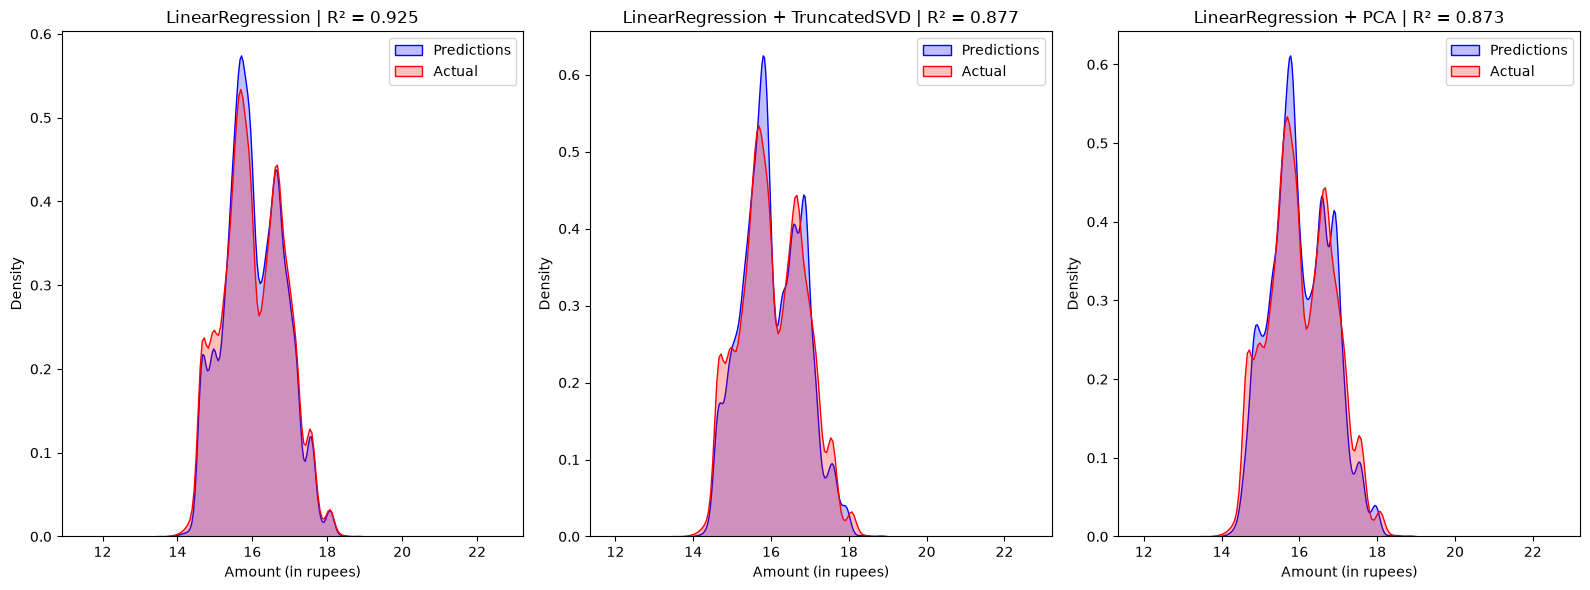

In [9]:
#LinearReg OneHotEncoder
target = "Amount(in rupees)"

X = data_2.drop(columns=[target]).copy()
y = data_2[target]

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

X[categorical_columns] = X[categorical_columns].fillna("NaN").astype(str)
X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].median())

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_columns),
        ("num", "passthrough", numeric_columns)
    ]
)

X_train, X_test, y_train_linreg, y_test_linreg = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

start = time.perf_counter()

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

model = LinearRegression()
model.fit(X_train_encoded, y_train_linreg)

fit_time_linreg = time.perf_counter() - start

y_pred_linreg = model.predict(X_test_encoded)

r2_linreg = r2_score(y_test_linreg, y_pred_linreg)
mae_linreg = mean_absolute_error(y_test_linreg, y_pred_linreg)
rmse_linreg = np.sqrt(mean_squared_error(y_test_linreg, y_pred_linreg))

#LinearReg + TruncatedSVD OneHotEncoder
X_train, X_test, y_train_svd, y_test_svd = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

start = time.perf_counter()

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


svd = TruncatedSVD(
    n_components=80,
    random_state=42
)

X_train_svd = svd.fit_transform(X_train_encoded)
X_test_svd = svd.transform(X_test_encoded)

model = LinearRegression()
model.fit(X_train_svd, y_train_svd)

fit_time_svd = time.perf_counter() - start

y_pred_svd = model.predict(X_test_svd)

r2_svd = r2_score(y_test_svd, y_pred_svd)
mae_svd = mean_absolute_error(y_test_svd, y_pred_svd)
rmse_svd = np.sqrt(mean_squared_error(y_test_svd, y_pred_svd))

# LinearReg + PCA OneHotEncoder
X_train, X_test, y_train_pca, y_test_pca = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

start = time.perf_counter()

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


pca = PCA(
    n_components=80,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train_encoded)
X_test_pca = pca.transform(X_test_encoded)


model = LinearRegression()
model.fit(X_train_pca, y_train_pca)

fit_time_pca = time.perf_counter() - start

y_pred_pca = model.predict(X_test_pca)
r2_pca = r2_score(y_test_pca, y_pred_pca)
mae_pca = mean_absolute_error(y_test_pca, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test_pca, y_pred_pca))


print("===== Linear Reg ================")
print(f"R2   = {r2_linreg:.3f}")
print(f"MAE  = {mae_linreg:.3f}")
print(f"RMSE = {rmse_linreg:.3f}")
print(f"TIME = {fit_time_linreg:.3f}")

print("\n=== Linear Reg + TruncatedSVD ===")
print(f"R2   = {r2_svd:.3f}")
print(f"MAE  = {mae_svd:.3f}")
print(f"RMSE = {rmse_svd:.3f}")
print(f"TIME = {fit_time_svd:.3f}")

print(f"SVD components = {svd.n_components}")
print(f"Explained variance = {svd.explained_variance_ratio_.sum():.3f}")

print("\n=== Linear Reg + PCA ===")
print(f"R2   = {r2_pca:.3f}")
print(f"MAE  = {mae_pca:.3f}")
print(f"RMSE = {rmse_pca:.3f}")
print(f"TIME = {fit_time_pca:.3f}")

print(f"PCA components = {pca.n_components}")
print(f"Explained variance = {pca.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
sns.kdeplot(y_pred_linreg, label="Predictions", fill=True, color="blue")
sns.kdeplot(y_test_linreg, label="Actual", fill=True, color="red")
plt.xlabel("Amount (in rupees)")
plt.ylabel("Density")
plt.title(f"LinearRegression | R² = {r2_linreg:.3f}")
plt.legend()

plt.subplot(1, 3, 2)
sns.kdeplot(y_pred_svd, label="Predictions", fill=True, color="blue")
sns.kdeplot(y_test_svd, label="Actual", fill=True, color="red")
plt.xlabel("Amount (in rupees)")
plt.ylabel("Density")
plt.title(f"LinearRegression + TruncatedSVD | R² = {r2_svd:.3f}")
plt.legend()

plt.subplot(1, 3, 3)
sns.kdeplot(y_pred_pca, label="Predictions", fill=True, color="blue")
sns.kdeplot(y_test_pca, label="Actual", fill=True, color="red")
plt.xlabel("Amount (in rupees)")
plt.ylabel("Density")
plt.title(f"LinearRegression + PCA | R² = {r2_pca:.3f}")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
components = [1,2,4,6,8,12,16,24,32,48,64,96,128,192,256,384,512,768,1024]

svd_r2 = []
svd_rmse = []
svd_mae = []
svd_variance = []

pca_r2 = []
pca_rmse = []
pca_mae = []
pca_variance = []

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

for n in components:
    svd = TruncatedSVD(
        n_components=n,
        random_state=42
    )

    X_train_svd = svd.fit_transform(X_train_encoded)
    X_test_svd = svd.transform(X_test_encoded)

    model_svd = LinearRegression()
    model_svd.fit(X_train_svd, y_train)

    y_pred_svd = model_svd.predict(X_test_svd)

    svd_r2.append(r2_score(y_test, y_pred_svd))
    svd_mae.append(mean_absolute_error(y_test, y_pred_svd))
    svd_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred_svd)))
    svd_variance.append(svd.explained_variance_ratio_.sum())

    pca = PCA(
        n_components=n,
        random_state=42
    )

    X_train_pca = pca.fit_transform(X_train_encoded)
    X_test_pca = pca.transform(X_test_encoded)

    model_pca = LinearRegression()
    model_pca.fit(X_train_pca, y_train)

    y_pred_pca = model_pca.predict(X_test_pca)

    pca_r2.append(r2_score(y_test, y_pred_pca))
    pca_mae.append(mean_absolute_error(y_test, y_pred_pca))
    pca_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred_pca)))
    pca_variance.append(pca.explained_variance_ratio_.sum())


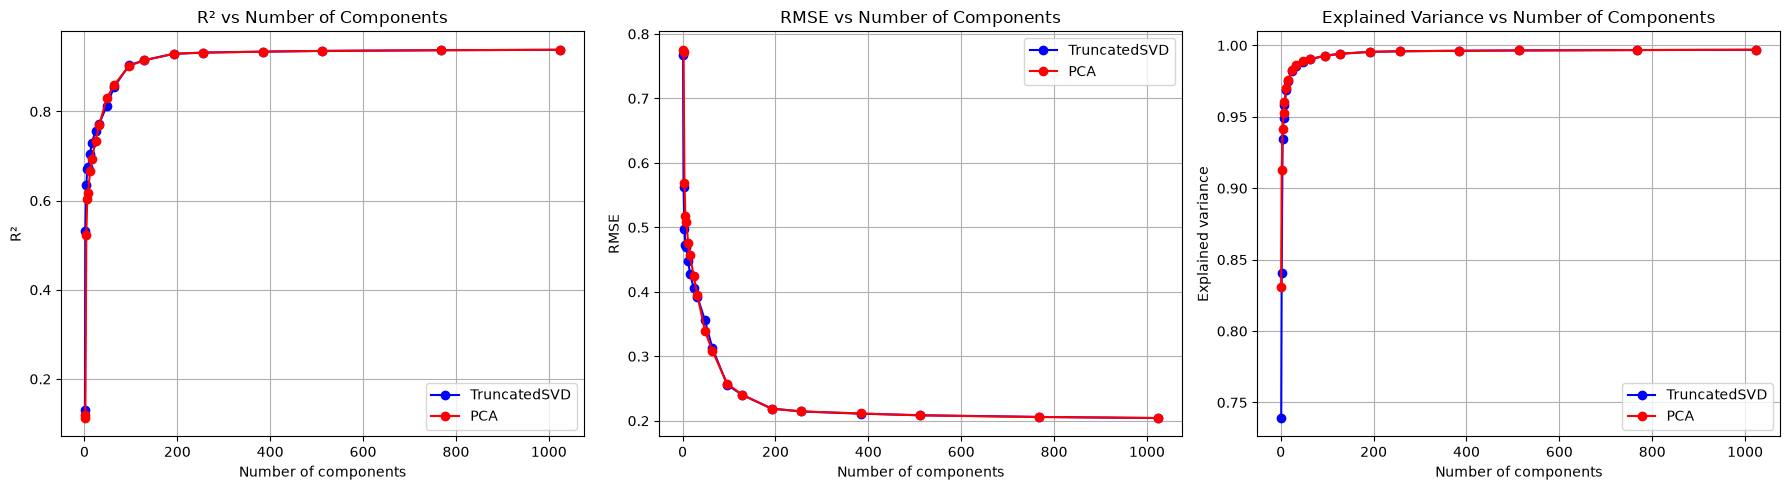

In [11]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)

plt.plot(components, svd_r2, marker="o", color="blue", label="TruncatedSVD")
plt.plot(components, pca_r2, marker="o", color="red", label="PCA")


plt.xlabel("Number of components")
plt.ylabel("R²")
plt.title("R² vs Number of Components")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)

plt.plot(components, svd_rmse, marker="o", color="blue", label="TruncatedSVD")
plt.plot(components, pca_rmse, marker="o", color="red", label="PCA")


plt.xlabel("Number of components")
plt.ylabel("RMSE")
plt.title("RMSE vs Number of Components")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)

plt.plot(components, svd_variance, marker="o", color="blue", label="TruncatedSVD")
plt.plot(components, pca_variance, marker="o", color="red", label="PCA")


plt.xlabel("Number of components")
plt.ylabel("Explained variance")
plt.title("Explained Variance vs Number of Components")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()